In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn pillow pandas gradio

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [ ]:
dataset_root = "./data"

dataset = OxfordIIITPet(
    root=dataset_root,
    split="trainval",
    target_types="category",
    download=True
)

print("Dataset loaded successfully")
print("Number of images:", len(dataset))
print("Number of classes:", len(dataset.classes))

100%|██████████| 792M/792M [00:24<00:00, 31.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.7MB/s]


Dataset loaded successfully
Number of images: 3680
Number of classes: 37


In [ ]:
for i, class_name in enumerate(dataset.classes):
    print(i, ":", class_name)

0 : Abyssinian
1 : American Bulldog
2 : American Pit Bull Terrier
3 : Basset Hound
4 : Beagle
5 : Bengal
6 : Birman
7 : Bombay
8 : Boxer
9 : British Shorthair
10 : Chihuahua
11 : Egyptian Mau
12 : English Cocker Spaniel
13 : English Setter
14 : German Shorthaired
15 : Great Pyrenees
16 : Havanese
17 : Japanese Chin
18 : Keeshond
19 : Leonberger
20 : Maine Coon
21 : Miniature Pinscher
22 : Newfoundland
23 : Persian
24 : Pomeranian
25 : Pug
26 : Ragdoll
27 : Russian Blue
28 : Saint Bernard
29 : Samoyed
30 : Scottish Terrier
31 : Shiba Inu
32 : Siamese
33 : Sphynx
34 : Staffordshire Bull Terrier
35 : Wheaten Terrier
36 : Yorkshire Terrier


In [ ]:
print("Total images:", len(dataset))
print("Total classes:", len(dataset.classes))

print("\nFirst image information:")

image, label = dataset[0]

print("Image size:", image.size)
print("Label number:", label)
print("Label name:", dataset.classes[label])

Total images: 3680
Total classes: 37

First image information:
Image size: (394, 500)
Label number: 0
Label name: Abyssinian


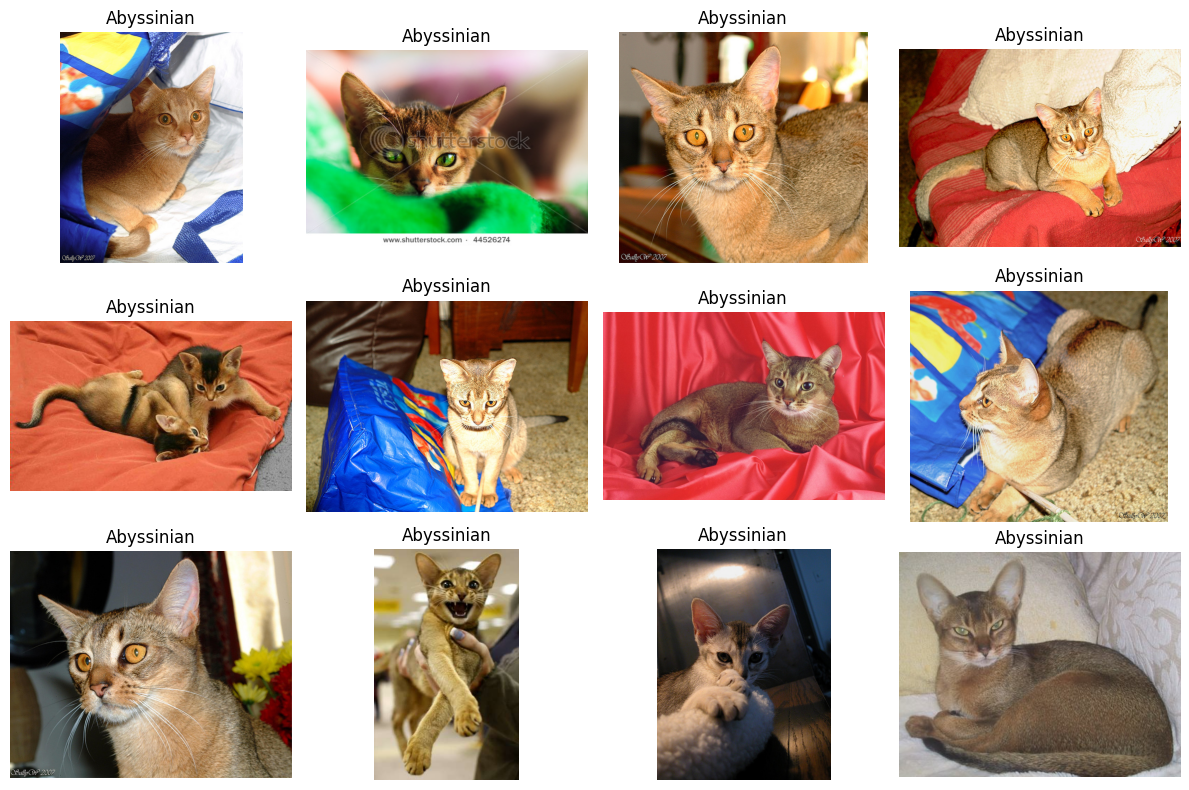

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    image, label = dataset[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(dataset.classes[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

From the sample images, we can observe:

different pet poses
different backgrounds
different lighting
different orientations
different animal sizes
visually similar breeds

These variations make breed classification more difficult.

In [ ]:
image_sizes = []

for i in range(len(dataset)):

    image, label = dataset[i]

    image_sizes.append(image.size)

widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Minimum width: 114
Maximum width: 3264
Minimum height: 108
Maximum height: 2606
Average width: 431.03342391304346
Average height: 383.4203804347826


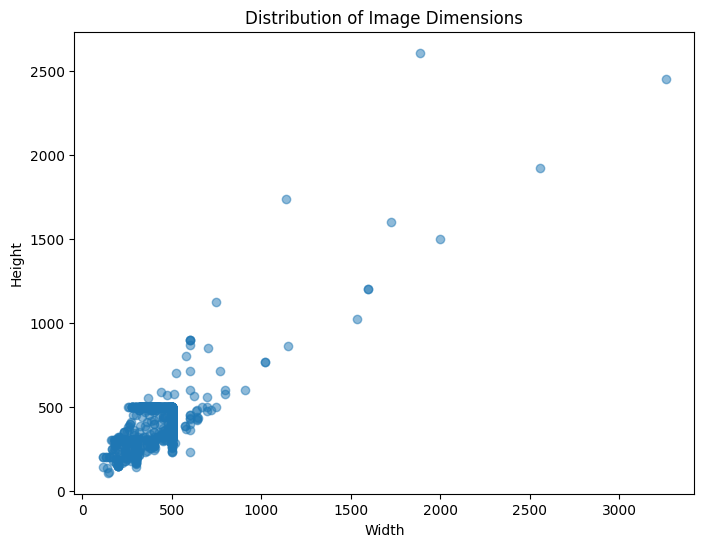

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    widths,
    heights,
    alpha=0.5
)

plt.xlabel("Width")
plt.ylabel("Height")

plt.title("Distribution of Image Dimensions")

plt.show()

The original images do not necessarily have the same dimensions.

In [ ]:
labels = []

for i in range(len(dataset)):

    image, label = dataset[i]

    labels.append(label)

class_counts = Counter(labels)

class_distribution = pd.DataFrame({
    "Class": [
        dataset.classes[i]
        for i in class_counts.keys()
    ],

    "Count": list(class_counts.values())
})

print(class_distribution)

                         Class  Count
0                   Abyssinian    100
1             American Bulldog    100
2    American Pit Bull Terrier    100
3                 Basset Hound    100
4                       Beagle    100
5                       Bengal    100
6                       Birman    100
7                       Bombay     96
8                        Boxer    100
9            British Shorthair    100
10                   Chihuahua    100
11                Egyptian Mau     93
12      English Cocker Spaniel     96
13              English Setter    100
14          German Shorthaired    100
15              Great Pyrenees    100
16                    Havanese    100
17               Japanese Chin    100
18                    Keeshond    100
19                  Leonberger    100
20                  Maine Coon    100
21          Miniature Pinscher    100
22                Newfoundland     96
23                     Persian    100
24                  Pomeranian    100
25          

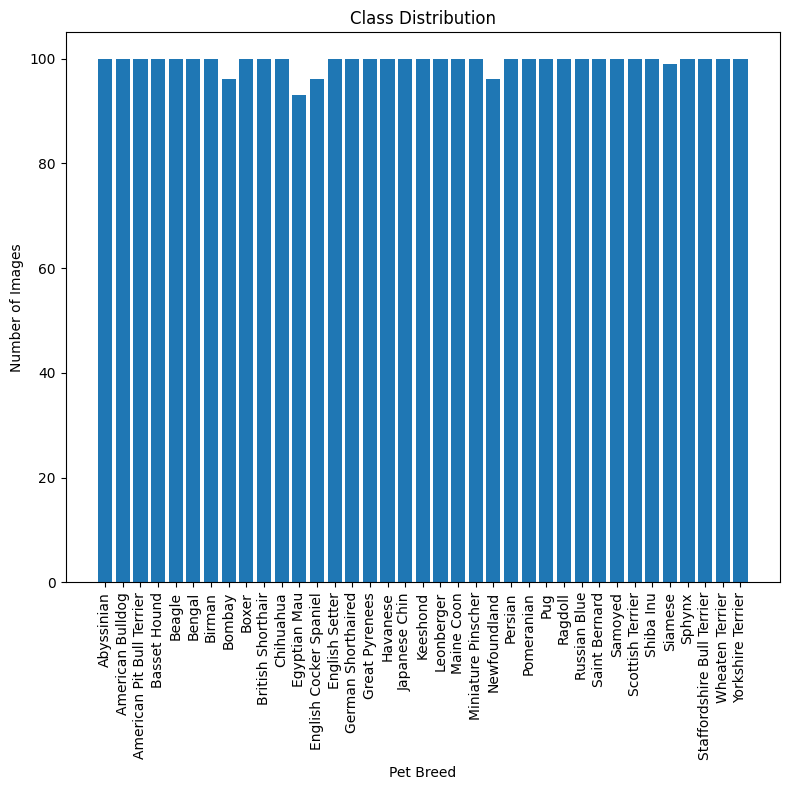

In [ ]:
plt.figure(figsize=(8, 8))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.xticks(rotation=90)

plt.xlabel("Pet Breed")
plt.ylabel("Number of Images")

plt.title("Class Distribution")

plt.tight_layout()

plt.show()

The dataset is approximately balanced because each breed contains roughly a similar number of images.

Therefore, class imbalance is not expected to be the main problem.

The bigger challenge is that some breeds look very similar.

In [ ]:
IMAGE_SIZE = 224
mean = [0.485,0.456,0.406]
std = [0.229,0.224,0.225]

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean,
        std
    )
])

In [ ]:
test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean,
        std
    )
])

This helps prevent data leakage and keeps evaluation consistent.

In [ ]:
trainval_dataset = OxfordIIITPet(
    root=dataset_root,
    split="trainval",
    target_types="category",
    download=True
)

test_dataset = OxfordIIITPet(
    root=dataset_root,
    split="test",
    target_types="category",
    download=True
)

print("Train + Validation:", len(trainval_dataset))
print("Test:", len(test_dataset))

Train + Validation: 3680
Test: 3669


In [ ]:
train_size = int(
    0.8 * len(trainval_dataset)
)

val_size = (
    len(trainval_dataset)
    - train_size
)

generator = torch.Generator().manual_seed(42)

train_indices, val_indices = torch.utils.data.random_split(
    range(len(trainval_dataset)),
    [train_size, val_size],
    generator=generator
)

train_indices = train_indices.indices
val_indices = val_indices.indices

print("Training:", len(train_indices))
print("Validation:", len(val_indices))
print("Testing:", len(test_dataset))

Training: 2944
Validation: 736
Testing: 3669


In [ ]:
train_base = OxfordIIITPet(
    root=dataset_root,
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)

val_base = OxfordIIITPet(
    root=dataset_root,
    split="trainval",
    target_types="category",
    download=True,
    transform=test_transform
)

In [ ]:
train_dataset = Subset(
    train_base,
    train_indices
)

val_dataset = Subset(
    val_base,
    val_indices
)

test_dataset = OxfordIIITPet(
    root=dataset_root,
    split="test",
    target_types="category",
    download=True,
    transform=test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2944
Validation: 736
Test: 3669


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully")

DataLoaders created successfully


In [ ]:
images, labels = next(
    iter(train_loader)
)

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)

Image shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [ ]:
class CustomCNN(nn.Module):

    def __init__(self, num_classes=37):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(256, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [ ]:
custom_model = CustomCNN(
    num_classes=len(dataset.classes)
)

custom_model = custom_model.to(device)

print(custom_model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    custom_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

crossEntropyLoss:
Suitable for 37-class classification.

Adam:
A commonly used optimizer that adapts the learning rate for different parameters.

Weight decay:
Helps reduce overfitting.

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    loss = total_loss / len(loader)

    accuracy = (
        correct / total
    ) * 100

    return loss, accuracy

In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    loss = total_loss / len(loader)

    accuracy = (
        correct / total
    ) * 100

    return loss, accuracy

In [ ]:
EPOCHS = 2

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    train_loss, train_acc = train_one_epoch(
        custom_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        custom_model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_acc:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc:.2f}%"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            custom_model.state_dict(),
            "best_custom_cnn.pth"
        )

print(
    "\nBest validation accuracy:",
    best_val_accuracy
)


Epoch 1/2
Train Loss: 3.3415
Train Accuracy: 9.65%
Validation Loss: 3.5444
Validation Accuracy: 8.29%

Epoch 2/2
Train Loss: 3.3114
Train Accuracy: 10.73%
Validation Loss: 3.3290
Validation Accuracy: 9.24%

Best validation accuracy: 9.239130434782608


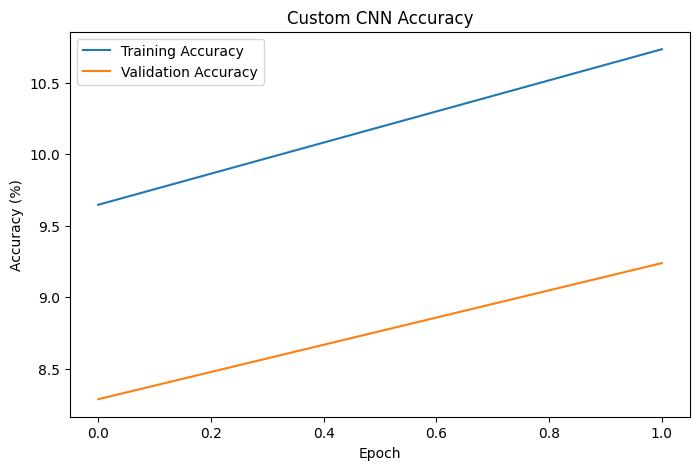

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Custom CNN Accuracy")

plt.legend()

plt.show()

If training accuracy keeps increasing but validation accuracy stops increasing or decreases, that indicates overfitting.

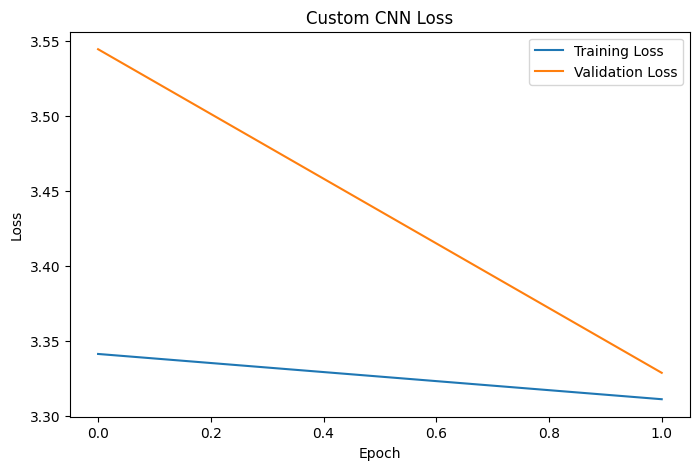

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Custom CNN Loss")

plt.legend()

plt.show()

In [ ]:
weights = models.ResNet18_Weights.DEFAULT

resnet_model = models.resnet18(
    weights=weights
)

print("ResNet18 loaded successfully")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 86.7MB/s]


ResNet18 loaded successfully


In [ ]:
for parameter in resnet_model.parameters():

    parameter.requires_grad = False

This means the pretrained feature extractor is frozen.

In [ ]:
num_features = (
    resnet_model.fc.in_features
)

resnet_model.fc = nn.Linear(
    num_features,
    len(dataset.classes)
)

resnet_model = resnet_model.to(device)

print(resnet_model.fc)

Linear(in_features=512, out_features=37, bias=True)


In [ ]:
criterion_resnet = nn.CrossEntropyLoss()

optimizer_resnet = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

In [ ]:
resnet_epochs = 2

resnet_train_acc = []
resnet_val_acc = []

best_resnet_accuracy = 0

for epoch in range(resnet_epochs):

    print(
        f"\nEpoch {epoch + 1}/{resnet_epochs}"
    )

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        criterion_resnet,
        optimizer_resnet,
        device
    )

    val_loss, val_acc = validate(
        resnet_model,
        val_loader,
        criterion_resnet,
        device
    )

    resnet_train_acc.append(train_acc)
    resnet_val_acc.append(val_acc)

    print(
        f"Train Accuracy: {train_acc:.2f}%"
    )

    print(
        f"Validation Accuracy: {val_acc:.2f}%"
    )

    if val_acc > best_resnet_accuracy:

        best_resnet_accuracy = val_acc

        torch.save(
            resnet_model.state_dict(),
            "best_resnet_feature_extractor.pth"
        )


Epoch 1/2
Train Accuracy: 48.68%
Validation Accuracy: 77.31%

Epoch 2/2
Train Accuracy: 78.43%
Validation Accuracy: 82.20%


In [ ]:
for parameter in resnet_model.layer4.parameters():

    parameter.requires_grad = True

In [ ]:
optimizer_finetune = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet_model.parameters()
    ),
    lr=0.0001,
    weight_decay=0.0001
)

criterion_finetune = nn.CrossEntropyLoss()

We use a smaller learning rate:

0.0001

because pretrained weights already contain useful information.

In [ ]:
fine_tune_epochs = 2

finetune_train_acc = []
finetune_val_acc = []

best_finetune_accuracy = 0

for epoch in range(fine_tune_epochs):

    print(
        f"\nFine-Tuning Epoch "
        f"{epoch + 1}/{fine_tune_epochs}"
    )

    train_loss, train_acc = train_one_epoch(
        resnet_model,
        train_loader,
        criterion_finetune,
        optimizer_finetune,
        device
    )

    val_loss, val_acc = validate(
        resnet_model,
        val_loader,
        criterion_finetune,
        device
    )

    finetune_train_acc.append(
        train_acc
    )

    finetune_val_acc.append(
        val_acc
    )

    print(
        f"Train Accuracy: {train_acc:.2f}%"
    )

    print(
        f"Validation Accuracy: {val_acc:.2f}%"
    )

    if val_acc > best_finetune_accuracy:

        best_finetune_accuracy = val_acc

        torch.save(
            resnet_model.state_dict(),
            "best_resnet_finetuned.pth"
        )

print(
    "Best fine-tuned validation accuracy:",
    best_finetune_accuracy
)


Fine-Tuning Epoch 1/2
Train Accuracy: 86.07%
Validation Accuracy: 88.72%

Fine-Tuning Epoch 2/2
Train Accuracy: 93.55%
Validation Accuracy: 89.27%
Best fine-tuned validation accuracy: 89.2663043478261


In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "ResNet18 Feature Extractor",
        "ResNet18 Fine-Tuned"
    ],

    "Best Validation Accuracy": [
        max(val_accuracies),
        max(resnet_val_acc),
        max(finetune_val_acc)
    ]
})

comparison

,Model,Best Validation Accuracy
0,Custom CNN,9.239130
1,ResNet18 Feature Extractor,82.201087
2,ResNet18 Fine-Tuned,89.266304


In [ ]:
resnet_model.load_state_dict(
    torch.load(
        "best_resnet_finetuned.pth",
        map_location=device
    )
)

resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = resnet_model(
            images
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [ ]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Accuracy: 85.77%


In [ ]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall: {recall:.4f}"
)

print(
    f"F1-score: {f1:.4f}"
)

Precision: 0.8698
Recall: 0.8577
F1-score: 0.8562


Accuracy: Overall percentage of correct predictions.

Precision: How often predictions for a class are correct.

Recall: How many actual samples of a class were correctly identified.

F1-score: Balance between precision and recall.

In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes,
        digits=4
    )
)

                            precision    recall  f1-score   support

                Abyssinian     0.8723    0.8367    0.8542        98
          American Bulldog     0.5986    0.8800    0.7126       100
 American Pit Bull Terrier     0.8182    0.3600    0.5000       100
              Basset Hound     0.9740    0.7500    0.8475       100
                    Beagle     0.7368    0.9800    0.8412       100
                    Bengal     0.7692    0.9000    0.8295       100
                    Birman     0.8072    0.6700    0.7322       100
                    Bombay     0.8842    0.9545    0.9180        88
                     Boxer     0.6643    0.9394    0.7782        99
         British Shorthair     0.9101    0.8100    0.8571       100
                 Chihuahua     0.8810    0.7400    0.8043       100
              Egyptian Mau     0.9753    0.8144    0.8876        97
    English Cocker Spaniel     0.9551    0.8500    0.8995       100
            English Setter     0.9579    0.9100

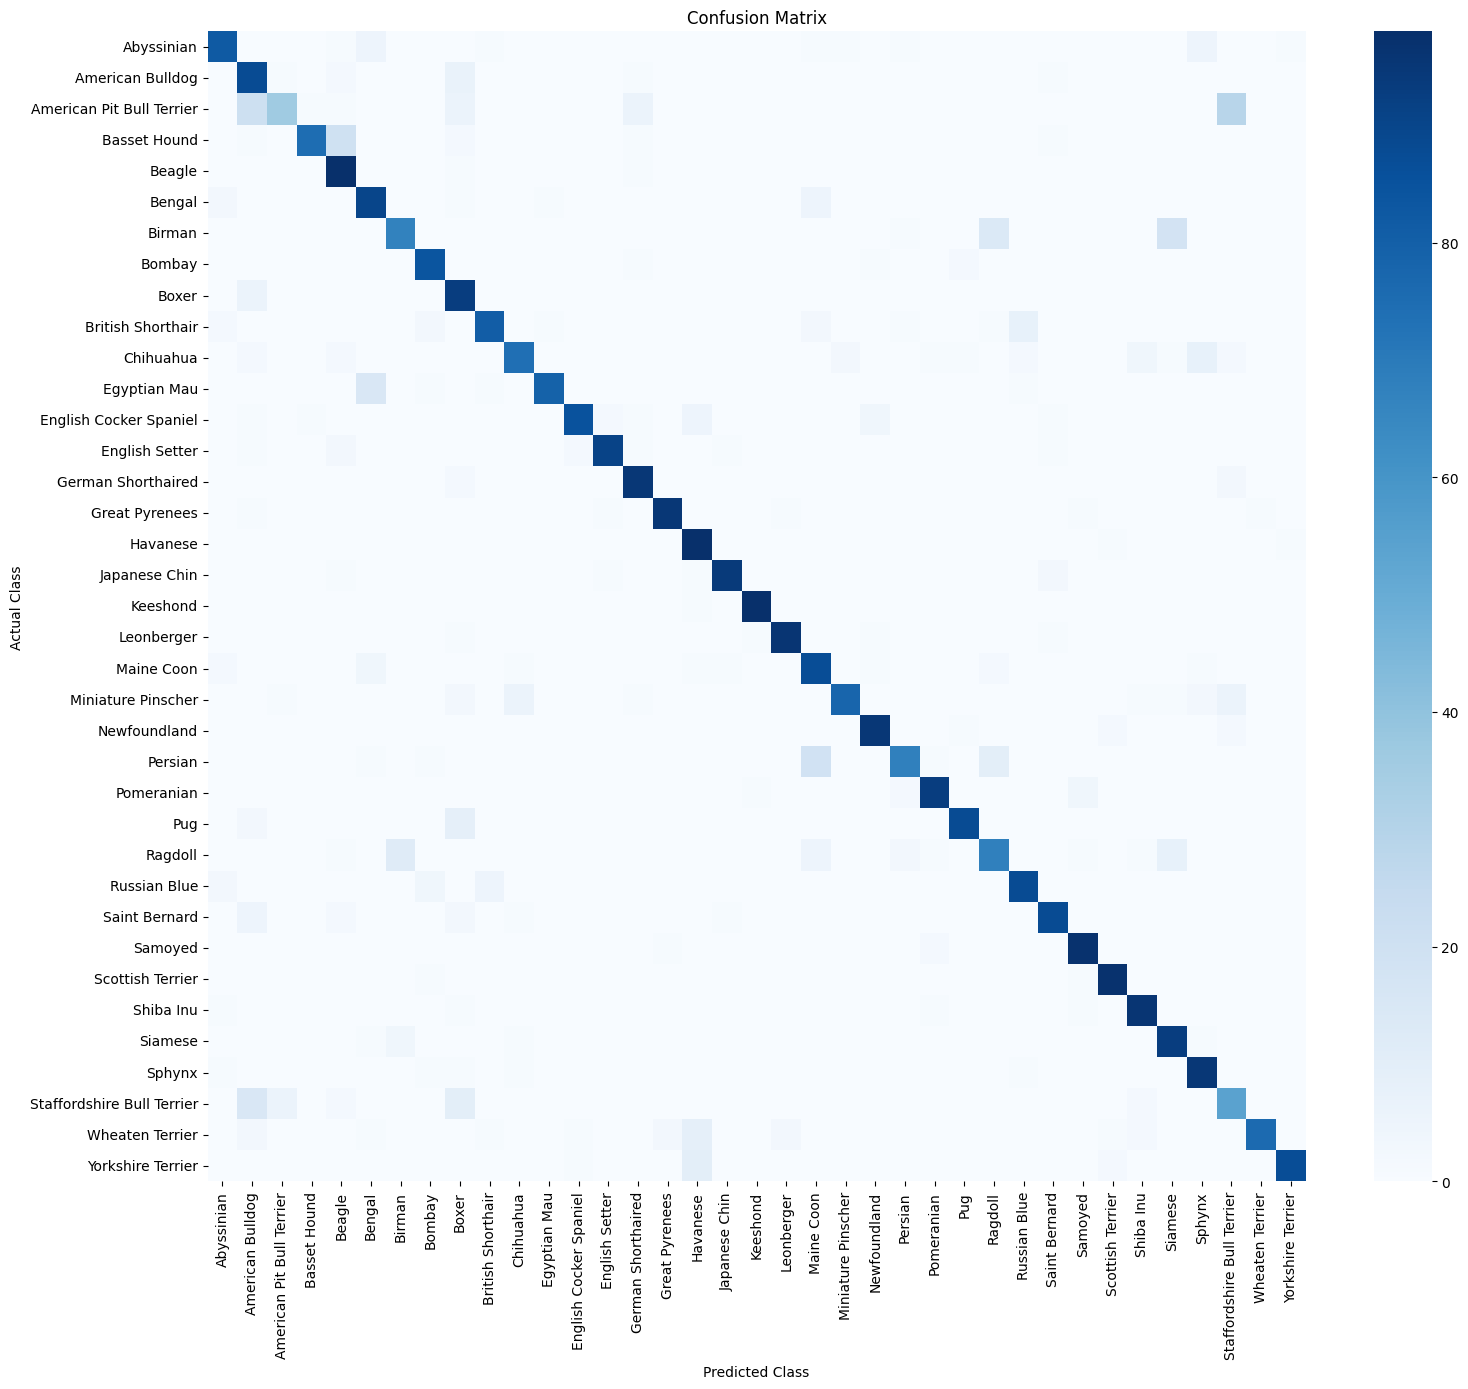

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

The confusion matrix tells us which breeds the model confuses with each other.

In [ ]:
torch.save(
    {
        "model_state_dict":
            resnet_model.state_dict(),

        "class_names":
            dataset.classes,

        "image_size":
            224,

        "mean":
            mean,

        "std":
            std
    },

    "oxford_pet_final_model.pth"
)

print(
    "Final model saved successfully."
)

Final model saved successfully.


In [ ]:
def predict_image(
    image_path,
    model,
    class_names,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = test_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(
        0
    )

    image_tensor = image_tensor.to(
        device
    )

    model.eval()

    with torch.no_grad():

        output = model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            1
        )

    predicted_class = class_names[
        predicted.item()
    ]

    confidence = (
        confidence.item() * 100
    )

    plt.figure(figsize=(6, 6))

    plt.imshow(image)

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")

    plt.show()

    return predicted_class, confidence

In [ ]:
import gradio as gr

In [ ]:
def classify_pet(image):

    image = image.convert("RGB")

    image_tensor = test_transform(
        image
    ).unsqueeze(0).to(device)

    resnet_model.eval()

    with torch.no_grad():

        output = resnet_model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )[0]

    top_probabilities, top_indices = torch.topk(
        probabilities,
        5
    )

    results = {}

    for probability, index in zip(
        top_probabilities,
        top_indices
    ):

        results[
            dataset.classes[index.item()]
        ] = float(probability)

    return results

In [ ]:
demo = gr.Interface(

    fn=classify_pet,

    inputs=gr.Image(
        type="pil",
        label="Upload Pet Image"
    ),

    outputs=gr.Label(
        num_top_classes=5,
        label="Predicted Breed"
    ),

    title="Oxford-IIIT Pet Breed Classifier",

    description=(
        "Upload a cat or dog image "
        "to predict its breed."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5f3acb349b70461cdd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
